In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split
x = data.drop(['median_house_value'],axis = 1)
y = data['median_house_value']

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [9]:
train_data = x_train.join(y_train)

In [10]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
9218,-120.27,37.12,42.0,1142.0,236.0,597.0,210.0,1.7279,INLAND,52300.0
12255,-117.02,33.76,20.0,1317.0,203.0,453.0,158.0,2.8393,INLAND,120700.0
4318,-118.34,34.09,52.0,1731.0,502.0,849.0,466.0,3.2946,<1H OCEAN,321600.0
18614,-122.07,37.06,31.0,1634.0,370.0,939.0,332.0,3.8625,NEAR OCEAN,232300.0
10275,-117.87,33.86,28.0,2292.0,531.0,2197.0,509.0,3.4856,<1H OCEAN,142800.0
...,...,...,...,...,...,...,...,...,...,...
5924,-117.76,34.13,8.0,16759.0,2274.0,7249.0,2156.0,7.4837,INLAND,358700.0
9498,-123.73,39.17,20.0,4620.0,1042.0,1745.0,794.0,2.3750,NEAR OCEAN,158800.0
551,-122.26,37.77,52.0,1704.0,371.0,663.0,340.0,4.2260,NEAR BAY,275000.0
14875,-117.08,32.63,33.0,2891.0,793.0,1607.0,754.0,2.1281,NEAR OCEAN,139800.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

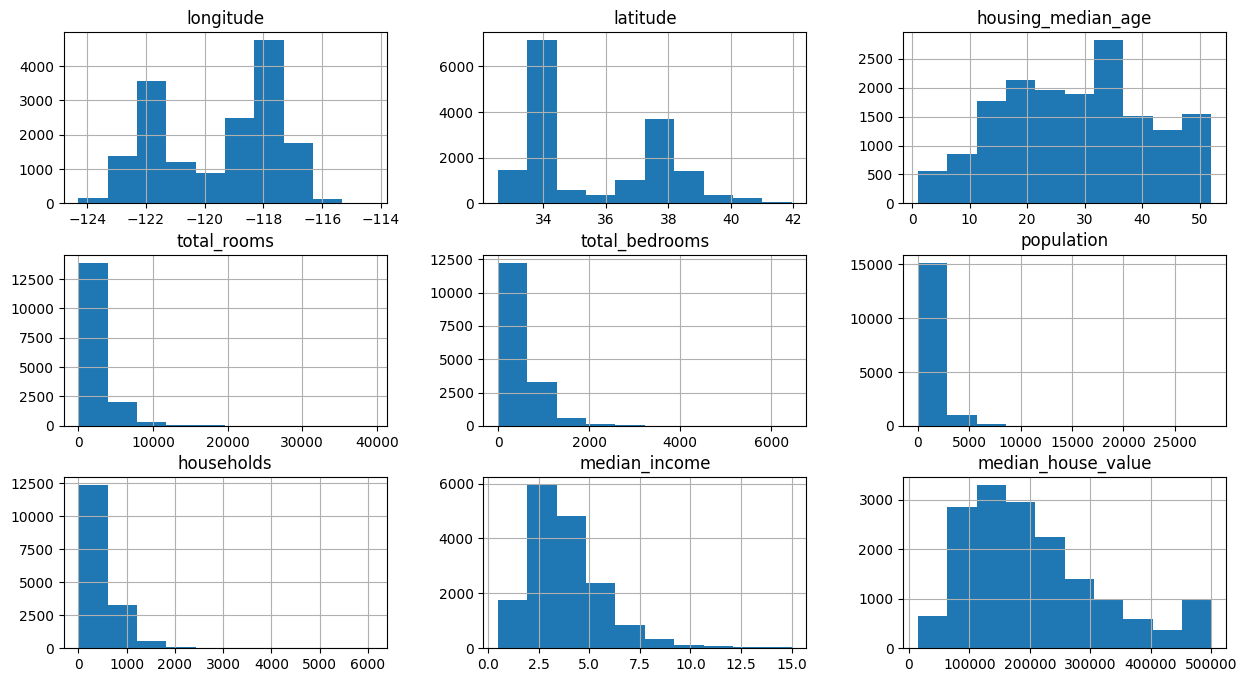

In [11]:
train_data.hist(figsize = (15,8))

<Axes: >

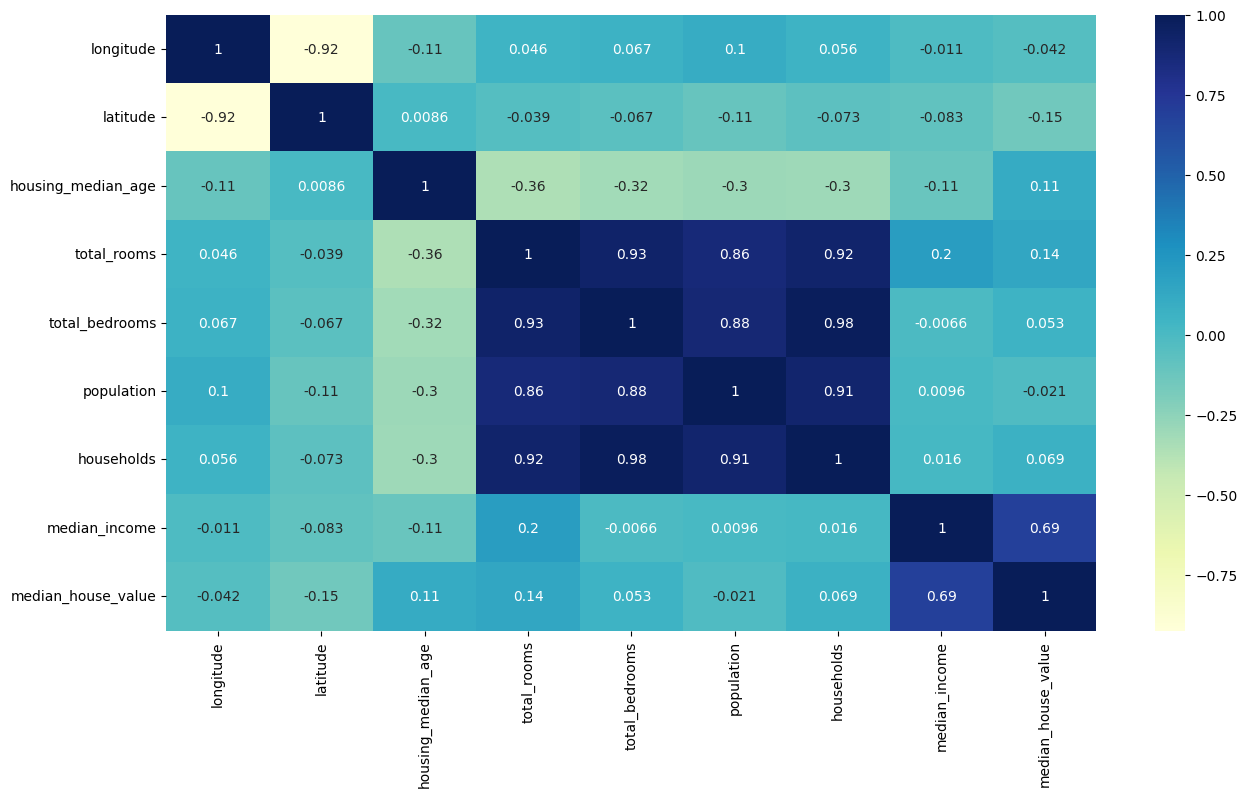

In [12]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),cmap = "YlGnBu",annot=True)

In [13]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

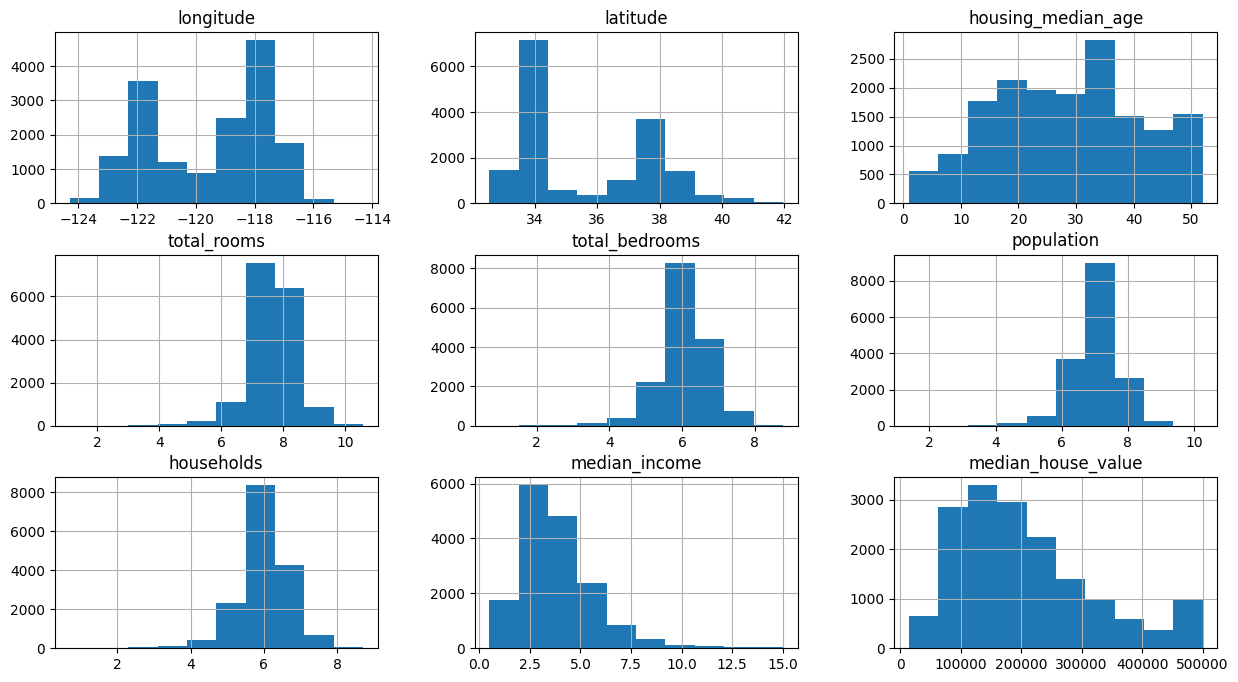

In [14]:
train_data.hist(figsize=(15,8))

In [15]:
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'],axis = 1)

<Axes: >

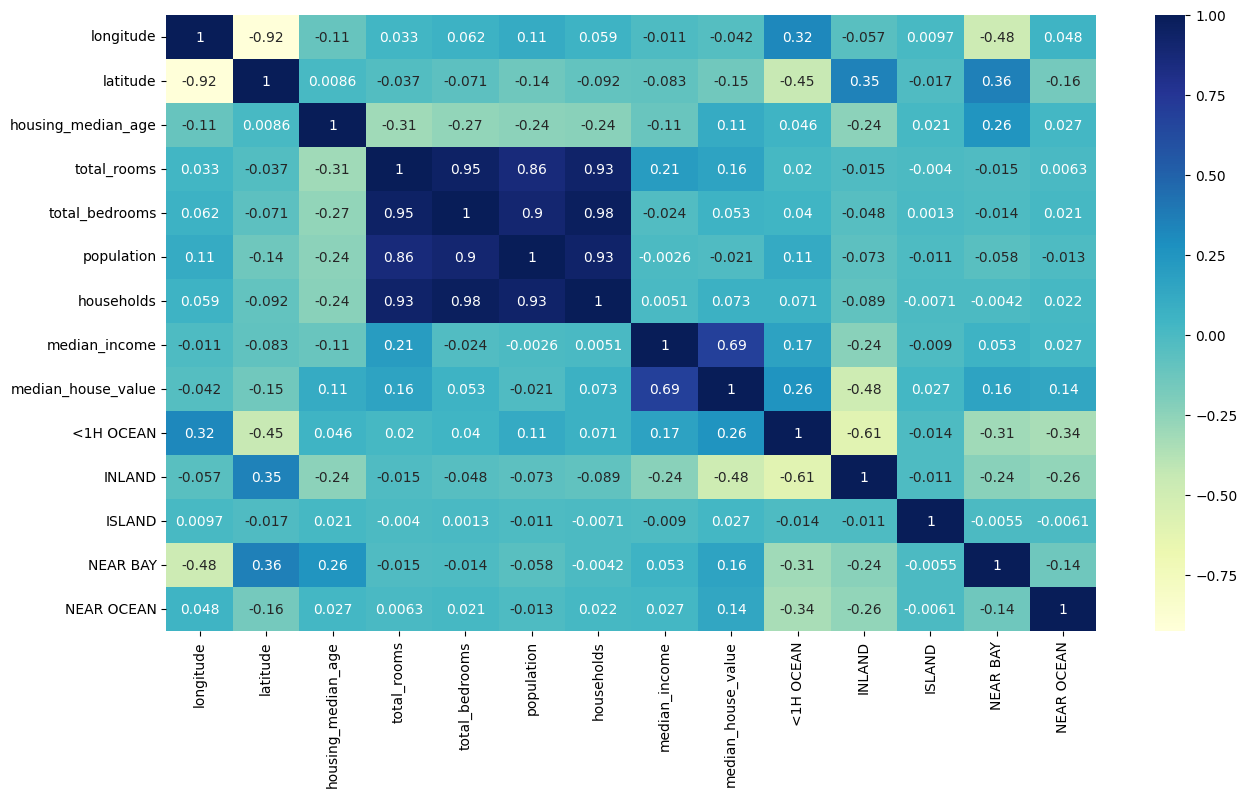

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),cmap = "YlGnBu",annot=True)

<Axes: xlabel='latitude', ylabel='longitude'>

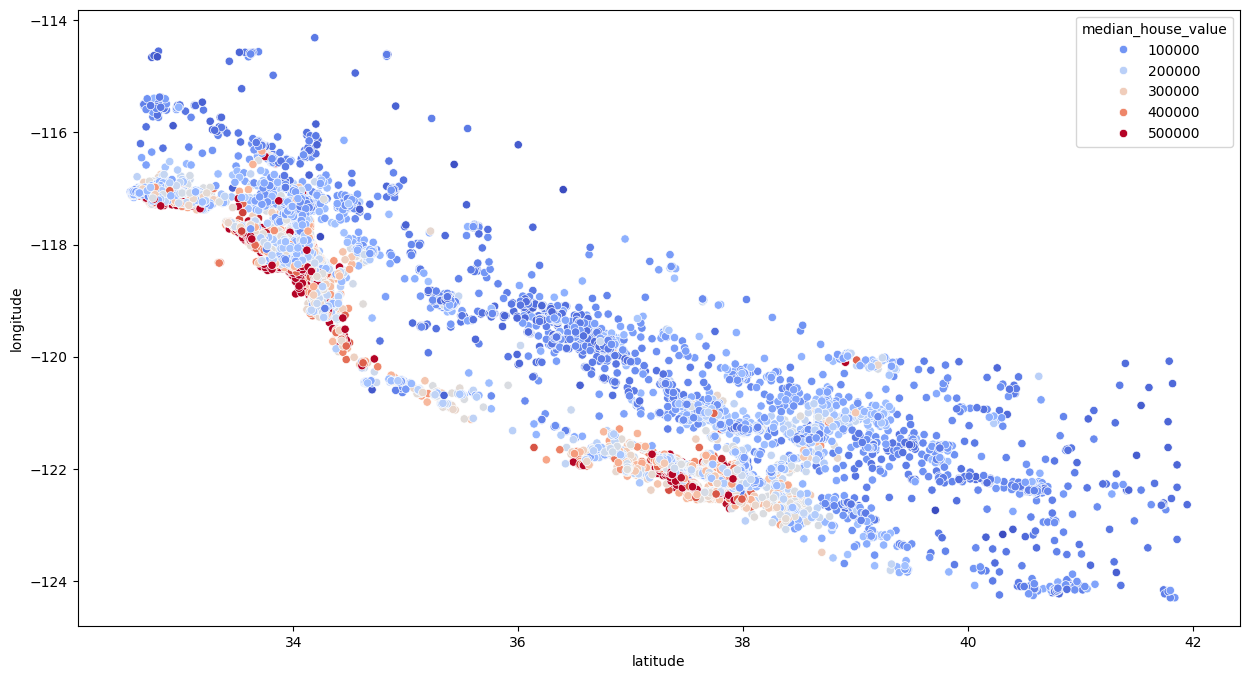

In [17]:
plt.figure(figsize=(15,8))
sns.scatterplot(y= "longitude",x="latitude",data=train_data,hue="median_house_value",palette="coolwarm")

In [18]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms'] 
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households'] 

<Axes: >

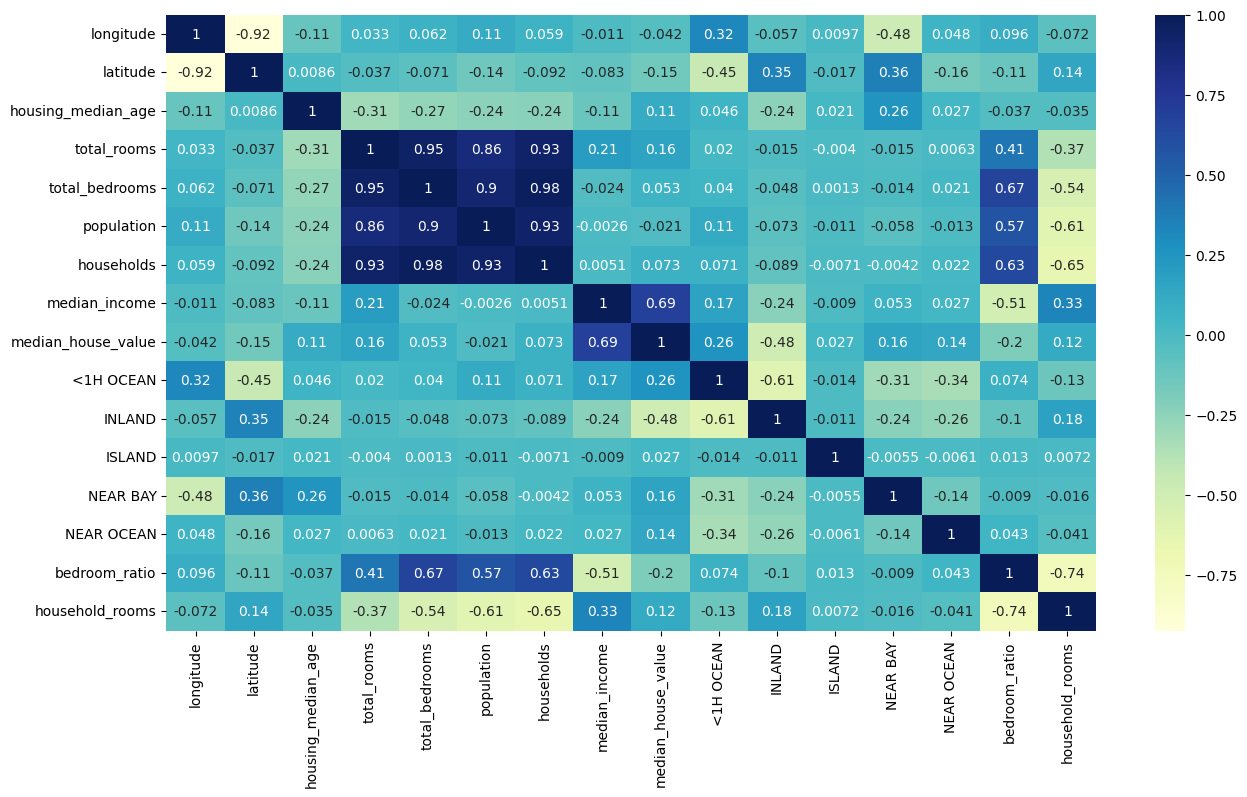

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),cmap = "YlGnBu",annot=True)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train,y_train = train_data.drop(['median_house_value'],axis = 1),train_data['median_house_value']
x_train_s = scale.fit_transform(x_train)
reg = LinearRegression()

reg.fit(x_train_s,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1) 

test_data = test_data.join(pd.get_dummies(test_data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'],axis = 1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms'] 
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

In [22]:
x_test,y_test = test_data.drop(['median_house_value'],axis=1),test_data['median_house_value']

In [23]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
9218,-120.27,37.12,42.0,7.041412,5.468060,6.393591,5.351858,1.7279,52300.0,0,1,0,0,0,0.776557,1.315695
12255,-117.02,33.76,20.0,7.183871,5.318120,6.118097,5.068904,2.8393,120700.0,0,1,0,0,0,0.740286,1.417243
4318,-118.34,34.09,52.0,7.457032,6.220590,6.745236,6.146329,3.2946,321600.0,1,0,0,0,0,0.834191,1.213250
18614,-122.07,37.06,31.0,7.399398,5.916202,6.845880,5.808142,3.8625,232300.0,0,0,0,0,1,0.799552,1.273970
10275,-117.87,33.86,28.0,7.737616,6.276643,7.695303,6.234411,3.4856,142800.0,1,0,0,0,0,0.811186,1.241114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5924,-117.76,34.13,8.0,9.726750,7.729735,8.888757,7.676474,7.4837,358700.0,0,1,0,0,0,0.794688,1.267086
9498,-123.73,39.17,20.0,8.438366,6.949856,7.465083,6.678342,2.3750,158800.0,0,0,0,0,1,0.823602,1.263542
551,-122.26,37.77,52.0,7.441320,5.918894,6.498282,5.831882,4.2260,275000.0,0,0,0,1,0,0.795409,1.275972
14875,-117.08,32.63,33.0,7.969704,6.677083,7.382746,6.626718,2.1281,139800.0,0,0,0,0,1,0.837808,1.202662


In [24]:
x_test_s = scale.transform(x_test)

In [25]:
reg.score(x_test_s,y_test)

0.6759684388508629

In [27]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(x_train_s,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
forest.score(x_test_s,y_test)

0.8136035557725346

In [ ]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators" : [100,200,300],
    "min_samples_split" : [2,4],
    "max_depth" : [None,4,8]
}

grid_search = GridSearchCV(forest,param_grid,cv=5,
                          scoring = "neg_mean_squared_error",
                           return_train_score=True)

grid_search.fit(x_train_s,y_train)

In [ ]:
best_forest = grid_search.best_estimator_

In [ ]:
best_forest.score(x_test_s,y_test)